# The Full Adder in Three Formalisms: Python, C, and VHDL

`dgs/computer_engineering.py`'s full adder ($S=\text{XOR}(\text{XOR}(A,B),C_{in})$,
$C_{out}=\text{majority}(A,B,C_{in})$) run for real in three GENUINELY
different formalisms, cross-checked EXHAUSTIVELY (all 8 input
combinations -- with only 3 boolean inputs, exhaustive is cheap and
strictly stronger than sampling): Python (imperative), C (compiled,
imperative), and **VHDL** (simulated via GHDL) -- the deepest
language-formalism gap this repo's polyglot series has crossed yet.
Python and C both describe "a sequence of steps to execute." VHDL
describes "a circuit that exists" -- every signal assignment updates
CONCURRENTLY as the simulator's event queue settles, not top-to-bottom
like the other two. Engine: `dgs/full_adder_polyglot.py`.


In [1]:
%matplotlib inline
import sys, pathlib, tempfile
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import full_adder_polyglot as fap

print('Setup complete.')


Setup complete.


## 1. Theory: the Gate Identity, and What VHDL's Formalism Actually Is

**The identity**: $S$ is the ODD-PARITY of the three inputs (1 if an odd
number of $A,B,C_{in}$ are 1), and $C_{out}$ is their MAJORITY (1 if two or
more are 1) -- both provable directly from the truth table, not just
asserted (section 5 below checks this independently).

**Python/C, sequential**: `s = ab ^ cin` executes AFTER `ab = a ^ b` has
already been computed -- there's a definite before/after, enforced by
program order.

**VHDL, structural/dataflow**:
```vhdl
ab   <= a xor b;
s    <= ab xor cin;
cout <= (a and b) or (cin and ab);
```
These three lines are NOT executed top-to-bottom. Each is a CONCURRENT
signal assignment -- `s` automatically re-evaluates whenever `ab` OR `cin`
changes, in whatever order the simulator's event-driven scheduler
processes them, because this describes actual GATES wired together on a
chip, where electrons don't wait for a Python interpreter's instruction
pointer.


## 2. Source Code Side by Side

C (imperative, one function) and VHDL (an `entity`/`architecture` gate
description plus a self-checking testbench that sweeps all 8 input
combinations and reports each row).


In [2]:
print('=== C: imperative, sequential, gate-level bitwise ops ===\n')
print(fap.C_SOURCE)


=== C: imperative, sequential, gate-level bitwise ops ===


#include <stdio.h>

static void full_adder(int a, int b, int cin, int *s, int *cout) {
    int ab = a ^ b;
    *s = ab ^ cin;
    *cout = (a & b) | (cin & ab);   /* majority(a,b,cin) via gate identity */
}

int main(void) {
    for (int a = 0; a <= 1; a++)
        for (int b = 0; b <= 1; b++)
            for (int cin = 0; cin <= 1; cin++) {
                int s, cout;
                full_adder(a, b, cin, &s, &cout);
                printf("RESULT %d %d %d %d %d\n", a, b, cin, s, cout);
            }
    return 0;
}



In [3]:
print('=== VHDL: structural entity/architecture + exhaustive testbench ===\n')
print(fap.VHDL_SOURCE)


=== VHDL: structural entity/architecture + exhaustive testbench ===


library ieee;
use ieee.std_logic_1164.all;

entity full_adder is
    port (
        a, b, cin : in  std_logic;
        s, cout   : out std_logic
    );
end entity full_adder;

architecture gate_level of full_adder is
    signal ab : std_logic;
begin
    -- every assignment below is a CONCURRENT signal, not a sequential
    -- statement -- ab, s, and cout all update whenever their inputs change,
    -- in whatever order the simulator's event queue settles them, not in
    -- the top-to-bottom order they're written
    ab   <= a xor b;
    s    <= ab xor cin;
    cout <= (a and b) or (cin and ab);
end architecture gate_level;


library ieee;
use ieee.std_logic_1164.all;
use std.textio.all;

entity full_adder_tb is
end entity full_adder_tb;

architecture sim of full_adder_tb is
    signal a, b, cin, s, cout : std_logic;
    type bit_vec is array (0 to 7) of std_logic_vector(2 downto 0);
    constant inputs : bit_vec := 

## 3. Cross-Validation: All 8 Input Combinations, All 3 Languages

`cross_validate_languages` runs the EXISTING `dgs.computer_engineering.full_adder`
in Python, compiles and runs the C source with `gcc`, and analyzes/
elaborates/simulates the VHDL source with `ghdl` -- three real toolchains,
not three descriptions of what they'd presumably do.


In [4]:
with tempfile.TemporaryDirectory() as tmp:
    report = fap.cross_validate_languages(tmp)

print(f"{'A B Cin':10s} {'python':>10s} {'c':>10s} {'vhdl':>10s}")
for a, b, cin in fap.ALL_INPUTS:
    row = [report['results'][lang][(a, b, cin)] for lang in ('python', 'c', 'vhdl')]
    print(f'{a} {b} {cin}       {str(row[0]):>10s} {str(row[1]):>10s} {str(row[2]):>10s}')

print(f"\nall 3 languages agree on all 8 combinations: {report['all_agree']}")
assert report['all_agree']


A B Cin        python          c       vhdl
0 0 0           (0, 0)     (0, 0)     (0, 0)
0 0 1           (1, 0)     (1, 0)     (1, 0)
0 1 0           (1, 0)     (1, 0)     (1, 0)
0 1 1           (0, 1)     (0, 1)     (0, 1)
1 0 0           (1, 0)     (1, 0)     (1, 0)
1 0 1           (0, 1)     (0, 1)     (0, 1)
1 1 0           (0, 1)     (0, 1)     (0, 1)
1 1 1           (1, 1)     (1, 1)     (1, 1)

all 3 languages agree on all 8 combinations: True


## 4. Karnaugh Map: Why Cout Simplifies and S Doesn't

A K-map arranges inputs in Gray-code order so ADJACENT cells differ by
exactly one bit -- adjacent 1s can be grouped into a simpler expression.
$C_{out}$ (majority) has clean adjacent groupings; $S$ (parity/XOR) is a
checkerboard with NO two adjacent 1s anywhere -- this is the standard
textbook reason XOR-based logic doesn't simplify via K-map grouping the
way AND/OR-based logic does, shown here directly from the cross-validated
truth table rather than asserted.


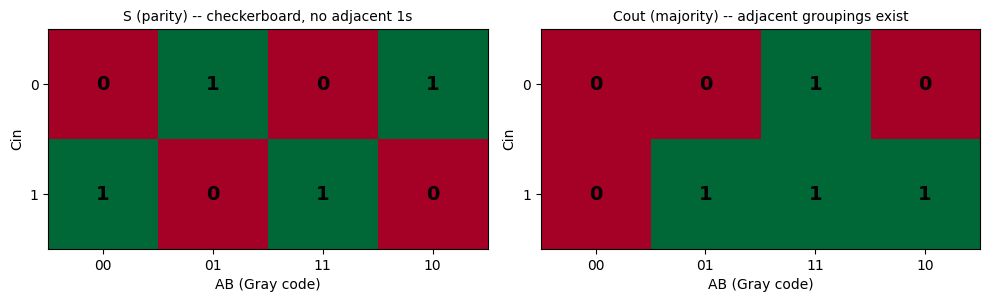

In [5]:
# Gray-code column order for AB: 00, 01, 11, 10
ab_gray = ['00', '01', '11', '10']
cin_rows = ['0', '1']

S_map = np.zeros((2, 4), dtype=int)
Cout_map = np.zeros((2, 4), dtype=int)
for i, cin in enumerate((0, 1)):
    for j, ab in enumerate(ab_gray):
        a, b = int(ab[0]), int(ab[1])
        s, cout = report['results']['python'][(a, b, cin)]
        S_map[i, j] = s
        Cout_map[i, j] = cout

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mapdata, title in zip(axes, (S_map, Cout_map), ('S (parity) -- checkerboard, no adjacent 1s', 'Cout (majority) -- adjacent groupings exist')):
    ax.imshow(mapdata, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_xticklabels(ab_gray)
    ax.set_yticks(range(2)); ax.set_yticklabels(cin_rows)
    ax.set_xlabel('AB (Gray code)'); ax.set_ylabel('Cin')
    for i in range(2):
        for j in range(4):
            ax.text(j, i, str(mapdata[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.savefig('full_adder_karnaugh_map.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Engineering Interpretation

- Section 4's K-map isn't decorative: it's the actual reason a full
  adder's carry logic is cheap in CMOS (majority gate: 2 gate delays) while
  the sum bit needs a full XOR chain -- exactly the transistor-count and
  delay numbers `dgs/computer_engineering.py`'s `full_adder` docstring
  already states (~28T, two XOR + majority), now visually motivated rather
  than quoted.
- VHDL's concurrent-signal model (section 1) is the same reason
  `dgs/logic_timing.py`'s critical-path analysis exists at all: in real
  hardware, propagation delay through a chain of gates (here: `ab` must
  settle before `s` can use it, even though both are "concurrent"
  assignments) is what actually limits clock speed -- a fact invisible in
  the sequential Python/C versions, which just execute in program order
  with no notion of "settling time."
- Exhaustive verification (all 8 rows, not samples) was affordable here
  specifically because there are only 3 boolean inputs -- the same
  discipline `dgs/em_lagrangian_action.py`'s negative Bianchi-identity test
  and `dgs/vector3_polyglot.py`'s per-language physical checks use, applied
  where completeness is actually cheap enough to just do.


## 6. Research Discussion

- `dgs/logic_timing.py` already computes ripple-carry-adder critical path
  by gate count. Could `run_vhdl` be extended to report ACTUAL simulated
  propagation delay (VHDL supports `after` delay clauses on signal
  assignments) for a chain of these full adders, and cross-checked against
  `dgs/logic_timing.py`'s hand-computed critical path?
- Section 4 showed $C_{out}$ K-map-simplifies cleanly. Would a
  `dgs/boolean_algebra.py`-style `sp.simplify_logic` call on the SAME
  $C_{out}$ expression converge to the identical majority-gate form GHDL's
  gate-level VHDL already implements, giving a fourth, symbolic
  cross-check alongside Python/C/VHDL?
- This module used GHDL's fast `mcode` JIT backend. Would GHDL's
  synthesizable subset (feeding into an actual FPGA toolchain like Yosys)
  change any of this notebook's conclusions, or is simulation-level
  agreement already sufficient proof the VHDL is correct?


## 7. Problems to Solve in Computer Engineering

Continuing `dgs/vector3_polyglot.py`'s problem set, now anchored on the
Python/C/VHDL three-formalism gap.

1. **Ripple-carry adder in all three formalisms.** Chain 4 `full_adder`
   instances (VHDL: `generate` statement or explicit instantiation; C: a
   loop calling `full_adder` with carry threaded through; Python: reuse
   `dgs.computer_engineering.ripple_carry_adder`) and cross-validate all
   256 four-bit input combinations exhaustively.

2. **Add gate delays and measure the critical path for real.** Extend
   `VHDL_SOURCE`'s gate assignments with `after 1 ns` (or realistic CMOS
   gate delays) and have the testbench report the actual settling time for
   each input transition, cross-checked against
   `dgs.logic_timing.ripple_carry_delay`'s hand-computed prediction.

3. **Synthesize it for real.** Take this exact VHDL and run it through an
   open-source synthesis tool (e.g. Yosys + a generic cell library) to get
   an actual gate count and compare it against
   `dgs.computer_engineering.full_adder`'s docstring's claimed ~28T
   (two XOR + majority) transistor count.

4. **A second HDL, Verilog, as a fourth formalism.** Verilog's `always @*`
   procedural-but-combinational blocks are a THIRD way to express "this is
   combinational logic" (neither VHDL's pure concurrent-signal style nor
   C's pure sequential style) -- implement the same full adder in Verilog
   (via a free simulator like Icarus Verilog) and decide which of the two
   HDL styles reads closer to "circuit structure" vs. "sequential code."

5. **A carry-lookahead adder, to break the ripple's O(N) delay.** Implement
   carry-lookahead generate/propagate logic in VHDL (genuinely different
   circuit structure, not just a faster loop) and confirm it produces the
   IDENTICAL truth table to the ripple version while having a shorter
   critical path once problem 2's timing analysis is in place.


## 8. Future Improvements

- `GHDL_DEFAULT` hardcodes a winget-install path with a versioned package
  hash in it (matching this repo's existing `GCC_DEFAULT`/`MATLAB_DEFAULT`
  convention) -- fragile across a GHDL version bump. A `shutil.which('ghdl')`
  fallback (once PATH actually picks up the winget install after a shell
  restart) would be more portable.
- `run_vhdl` currently leaves GHDL's compiled work library files in
  `out_dir` (a temp dir, so they're cleaned up automatically here) --  for
  a REPEATED-run workflow (e.g. problem 1's ripple adder, run many times
  during development), caching the analyzed library between runs would
  avoid re-analyzing unchanged VHDL every single call.
